In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv('data.csv', sep=';')
df= df.drop(columns=['Application mode', 'Application order'])
df = df[df["Target"].isin(["Dropout", "Graduate"])]
df.columns = df.columns.str.replace('\t', '', regex=True).str.strip()

In [3]:
df

,Marital status,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,171,1,1,122.0,1,19,12,5,9,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,9254,1,1,160.0,1,1,3,3,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,9070,1,1,122.0,1,37,37,9,9,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,9773,1,1,122.0,1,38,37,5,3,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,8014,0,1,100.0,1,37,38,9,9,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,9773,1,1,125.0,1,1,1,5,4,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,9773,1,1,120.0,105,1,1,9,9,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,9500,1,1,154.0,1,37,37,9,9,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,9147,1,1,180.0,1,37,37,7,4,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3630 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  3630 non-null   int64  
 1   Course                                          3630 non-null   int64  
 2   Daytime/evening attendance                      3630 non-null   int64  
 3   Previous qualification                          3630 non-null   int64  
 4   Previous qualification (grade)                  3630 non-null   float64
 5   Nacionality                                     3630 non-null   int64  
 6   Mother's qualification                          3630 non-null   int64  
 7   Father's qualification                          3630 non-null   int64  
 8   Mother's occupation                             3630 non-null   int64  
 9   Father's occupation                      

In [5]:
df.rename(columns = {'Nacionality':'Nationality', 'Age at enrollment':'Age'}, inplace = True)
df.isnull().sum()/len(df)*100

Marital status                                    0.0
Course                                            0.0
Daytime/evening attendance                        0.0
Previous qualification                            0.0
Previous qualification (grade)                    0.0
Nationality                                       0.0
Mother's qualification                            0.0
Father's qualification                            0.0
Mother's occupation                               0.0
Father's occupation                               0.0
Admission grade                                   0.0
Displaced                                         0.0
Educational special needs                         0.0
Debtor                                            0.0
Tuition fees up to date                           0.0
Gender                                            0.0
Scholarship holder                                0.0
Age                                               0.0
International               

In [6]:
# Suppose your full dataframe is 'df' and target column is 'target'
X1 = df.drop(columns=['Target'])   # all features
y1 = df['Target']                  # target variable

# If you have categorical features, encode them first
X_encoded = pd.get_dummies(X1, drop_first=True)

# Now calculate VIF
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X_encoded.columns
vif_data["VIF"] = [variance_inflation_factor(X_encoded.values, i) 
                   for i in range(X_encoded.shape[1])]

print(vif_data.sort_values(by="VIF", ascending=False))


                                           feature         VIF
20             Curricular units 1st sem (enrolled)  179.138458
26             Curricular units 2nd sem (enrolled)  151.511754
4                   Previous qualification (grade)  127.521784
10                                 Admission grade  115.592528
22             Curricular units 1st sem (approved)   51.640450
1                                           Course   41.985170
28             Curricular units 2nd sem (approved)   39.926218
23                Curricular units 1st sem (grade)   30.436629
29                Curricular units 2nd sem (grade)   28.651805
31                               Unemployment rate   23.498332
21          Curricular units 1st sem (evaluations)   19.373646
17                                             Age   19.361058
19             Curricular units 1st sem (credited)   18.834094
27          Curricular units 2nd sem (evaluations)   17.244607
25             Curricular units 2nd sem (credited)   14

#### Hypothesis Statements (for each feature)
##### Null Hypothesis (H₀):

- There is no association between the feature and the Target (Graduated/Dropout).

###### Alternative Hypothesis (H₁):

- There is an association between the feature and the Target.

In [7]:
import pandas as pd
from scipy.stats import chi2_contingency

# Assuming df is already defined
# df = pd.read_csv("your_dataset.csv")  # example

categorical_features = [
    "Daytime/evening attendance",
    "Displaced",
    "Course",
    "Tuition fees up to date",
    "Scholarship holder",
    "Debtor",
    "International",
    "Mother's qualification",
    "Mother's occupation",
    "Father's occupation"
]

target_col = "Target"

results = []

for col in categorical_features:
    contingency = pd.crosstab(df[col], df[target_col])
    chi2, p, dof, expected = chi2_contingency(contingency)
    results.append([col, chi2, p])

chi_df = pd.DataFrame(results, columns=["Feature", "Chi2 Score", "P-value"])
print(chi_df.sort_values("P-value"))


                      Feature  Chi2 Score        P-value
3     Tuition fees up to date  706.955139  9.189124e-156
2                      Course  442.947968   3.497695e-84
4          Scholarship holder  354.219302   5.109075e-79
5                      Debtor  257.459618   6.141424e-58
7      Mother's qualification  143.014288   2.201217e-17
8         Mother's occupation  138.235113   1.555138e-16
1                   Displaced   57.215216   3.906373e-14
9         Father's occupation  125.427955   1.725336e-10
0  Daytime/evening attendance   25.371410   4.728747e-07
6               International    0.067922   7.943867e-01


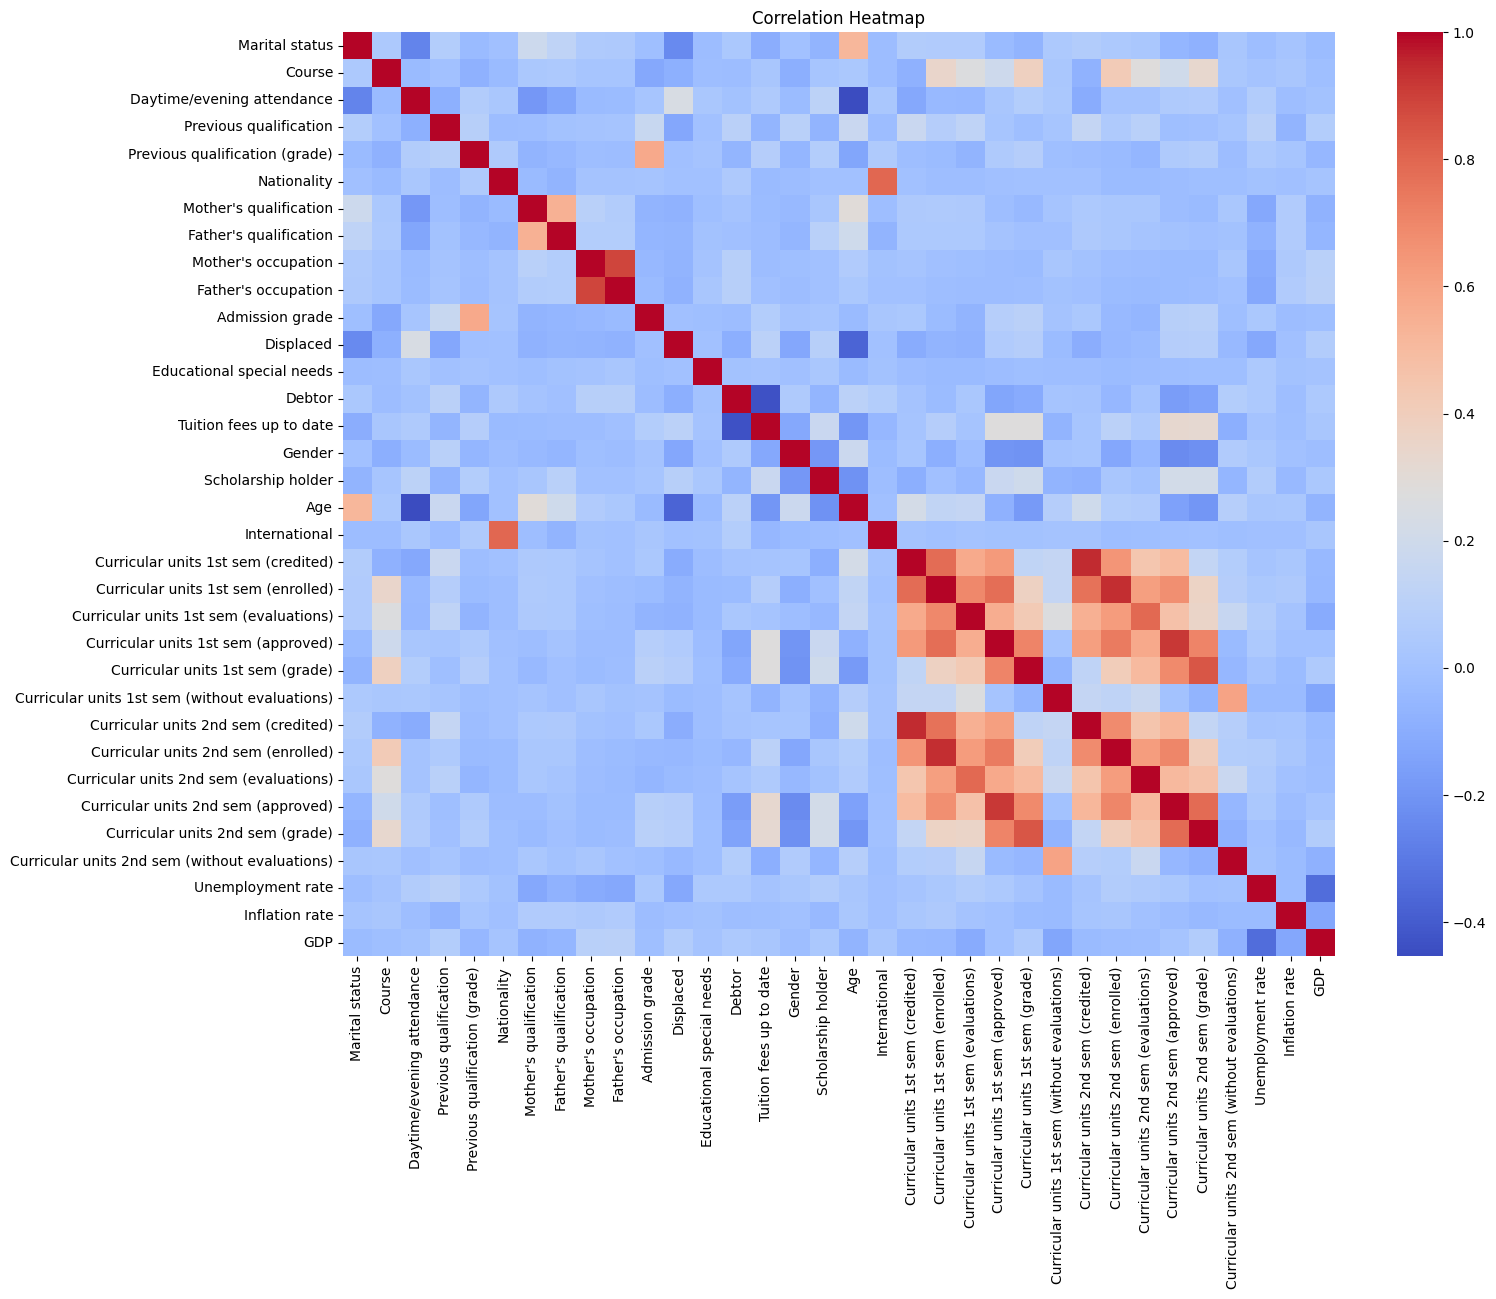

In [8]:
numeric_df = df.select_dtypes(include=['number'])

corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


- Curricular units 1st sem (approved)
- Curricular units 1st sem (grade)
- Curricular units 2nd sem (approved)
- Curricular units 2nd sem (grade)

In [9]:
from sklearn.feature_selection import f_classif
import pandas as pd

# Define only economic features
features = ['Unemployment rate', 'Inflation rate', 'GDP','Admission grade']

# Prepare X and y
X = df[features]
y = df['Target']

# Perform ANOVA F-test
f_scores, p_values = f_classif(X, y)

# Create results dataframe
anova_results = pd.DataFrame({
    'Feature': features,
    'F-Score': f_scores,
    'P-Value': p_values
}).sort_values('F-Score', ascending=False)

# Display results
print(anova_results)
print("\n=== Interpretation ===")
for i, feature in enumerate(features):
    significance = "Significant" if p_values[i] < 0.05 else "Not Significant"
    print(f"{feature}: F-Score={f_scores[i]:.2f}, P-Value={p_values[i]:.4f} - {significance}")

             Feature    F-Score       P-Value
3    Admission grade  60.486677  9.583914e-15
2                GDP   9.187836  2.453491e-03
1     Inflation rate   3.339591  6.771352e-02
0  Unemployment rate   0.063941  8.003859e-01

=== Interpretation ===
Unemployment rate: F-Score=0.06, P-Value=0.8004 - Not Significant
Inflation rate: F-Score=3.34, P-Value=0.0677 - Not Significant
GDP: F-Score=9.19, P-Value=0.0025 - Significant
Admission grade: F-Score=60.49, P-Value=0.0000 - Significant


In [10]:
from scipy.stats import f_oneway, ttest_ind

# Suppose target has 2 classes: 0 and 1
group0 = df[df['Target'] == 'Dropout']['Age']
group1 = df[df['Target'] == 'Graduate']['Age']

t_stat, p_val = ttest_ind(group0, group1)
print("t-test p-value:", p_val)


t-test p-value: 2.113885168983868e-60


XGBoost Hyperparameter Tuning Started...
Fitting 5 folds for each of 6561 candidates, totalling 32805 fits

XGBoost Best Parameters:
{'colsample_bytree': 0.6, 'gamma': 0.3, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 3, 'reg_alpha': 0.5, 'reg_lambda': 1.0, 'subsample': 0.8}
Best CV Log Loss: 0.2341

Random Forest Hyperparameter Tuning Started...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Random Forest Best Parameters:
{'bootstrap': True, 'max_depth': 12, 'max_features': 'log2', 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 200, 'oob_score': True}
Best CV Log Loss: 0.2552
OOB Score: 0.9021

XGBoost - Final Metrics
Train Accuracy: 0.9485
Test Accuracy: 0.9008
Accuracy Gap: 0.0477

Train Recall: 0.9734
Test Recall: 0.9548
Recall Gap: 0.0187

Train Log Loss: 0.1433
Test Log Loss: 0.2501
Log Loss Gap: 0.1068


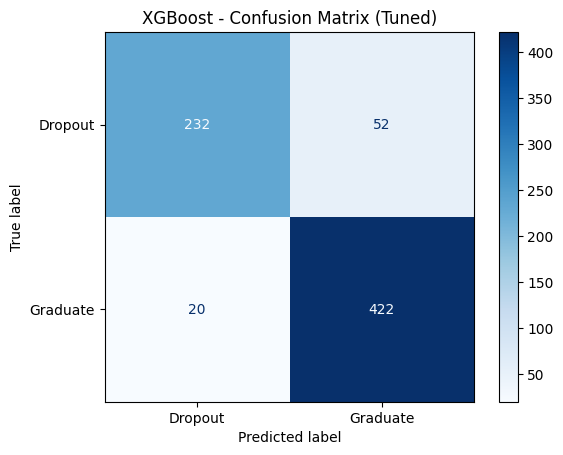


Random Forest - Final Metrics
Train Accuracy: 0.9403
Test Accuracy: 0.8981
Accuracy Gap: 0.0422

Train Recall: 0.9706
Test Recall: 0.9457
Recall Gap: 0.0249

Train Log Loss: 0.1778
Test Log Loss: 0.2639
Log Loss Gap: 0.0862


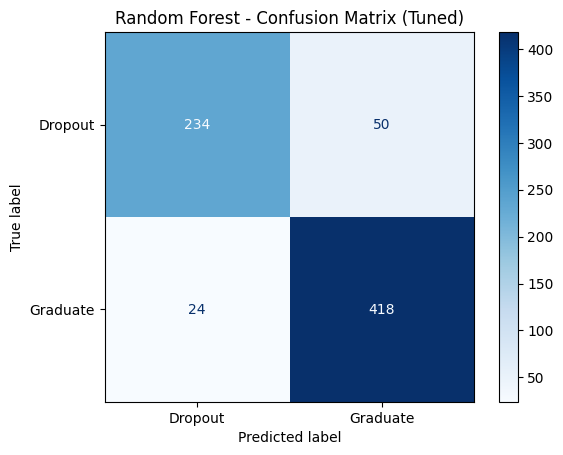


COMPARISON SUMMARY
        Model  Test Accuracy  Test Recall  Test Log Loss
      XGBoost       0.900826     0.954751       0.250094
Random Forest       0.898072     0.945701       0.263938

Best Model by Log Loss: XGBoost


In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, log_loss, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Features and target
# -----------------------------
numerical_features = [
    "Admission grade", "GDP", "Previous qualification",
    "Curricular units 1st sem (approved)", "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (approved)", "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)", "Age",
    "Tuition fees up to date", "Course", "Scholarship holder", "Debtor",
    "Mother's qualification", "Mother's occupation", "Father's occupation",
    "Displaced", "Daytime/evening attendance", "International"
]
target_col = "Target"
X = df[numerical_features].copy()
y = df[target_col].map({'Dropout': 0, 'Graduate': 1})

# -----------------------------
# Step 2: Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# Step 3: Standardize features
# -----------------------------
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# -----------------------------
# Step 4: Balance training data with SMOTE
# -----------------------------
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# -----------------------------
# Step 5a: XGBoost Hyperparameter Tuning
# -----------------------------
print("=" * 60)
print("XGBoost Hyperparameter Tuning Started...")
print("=" * 60)

xgb_param_grid = {
    'max_depth': [3, 4, 5],
    'min_child_weight': [3, 5, 7],
    'gamma': [0.1, 0.3, 0.5],
    'subsample': [0.6, 0.7, 0.8],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'learning_rate': [0.01, 0.03, 0.05],
    'reg_alpha': [0, 0.5, 1.0],
    'reg_lambda': [1.0, 2.0, 3.0]
}

xgb_base = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    n_estimators=200,
    random_state=42
)

xgb_grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=xgb_param_grid,
    scoring='neg_log_loss',
    cv=5,
    verbose=2,
    n_jobs=-1
)

xgb_grid.fit(X_train_res, y_train_res)

print("\n" + "=" * 60)
print("XGBoost Best Parameters:")
print("=" * 60)
print(xgb_grid.best_params_)
print(f"Best CV Log Loss: {-xgb_grid.best_score_:.4f}")

xgb_model = xgb_grid.best_estimator_

# -----------------------------
# Step 5b: Random Forest Hyperparameter Tuning
# -----------------------------
print("\n" + "=" * 60)
print("Random Forest Hyperparameter Tuning Started...")
print("=" * 60)

rf_param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [6, 8, 10, 12],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf': [5, 10, 15],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True],
    'oob_score': [True]
}

rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_grid = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    scoring='neg_log_loss',
    cv=5,
    verbose=2,
    n_jobs=-1
)

rf_grid.fit(X_train_res, y_train_res)

print("\n" + "=" * 60)
print("Random Forest Best Parameters:")
print("=" * 60)
print(rf_grid.best_params_)
print(f"Best CV Log Loss: {-rf_grid.best_score_:.4f}")
print(f"OOB Score: {rf_grid.best_estimator_.oob_score_:.4f}")

rf_model = rf_grid.best_estimator_

# -----------------------------
# Step 6: Predictions with Best Models
# -----------------------------
models = {"XGBoost": xgb_model, "Random Forest": rf_model}

for name, model in models.items():
    print(f"\n{'=' * 60}")
    print(f"{name} - Final Metrics")
    print("=" * 60)
    
    y_train_pred = model.predict(X_train_res)
    y_test_pred = model.predict(X_test)
    
    # Probabilities for log loss
    y_train_prob = model.predict_proba(X_train_res)[:,1]
    y_test_prob = model.predict_proba(X_test)[:,1]
    
    # Accuracy & Recall
    train_acc = accuracy_score(y_train_res, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    train_recall = recall_score(y_train_res, y_train_pred)
    test_recall = recall_score(y_test, y_test_pred)
    train_logloss = log_loss(y_train_res, y_train_prob)
    test_logloss = log_loss(y_test, y_test_prob)
    
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Accuracy Gap: {(train_acc - test_acc):.4f}")
    print(f"\nTrain Recall: {train_recall:.4f}")
    print(f"Test Recall: {test_recall:.4f}")
    print(f"Recall Gap: {(train_recall - test_recall):.4f}")
    print(f"\nTrain Log Loss: {train_logloss:.4f}")
    print(f"Test Log Loss: {test_logloss:.4f}")
    print(f"Log Loss Gap: {(test_logloss - train_logloss):.4f}")
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_test_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dropout','Graduate'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"{name} - Confusion Matrix (Tuned)")
    plt.show()

# -----------------------------
# Step 7: Compare Results
# -----------------------------
print("\n" + "=" * 60)
print("COMPARISON SUMMARY")
print("=" * 60)

results_df = pd.DataFrame({
    'Model': ['XGBoost', 'Random Forest'],
    'Test Accuracy': [
        accuracy_score(y_test, xgb_model.predict(X_test)),
        accuracy_score(y_test, rf_model.predict(X_test))
    ],
    'Test Recall': [
        recall_score(y_test, xgb_model.predict(X_test)),
        recall_score(y_test, rf_model.predict(X_test))
    ],
    'Test Log Loss': [
        log_loss(y_test, xgb_model.predict_proba(X_test)[:,1]),
        log_loss(y_test, rf_model.predict_proba(X_test)[:,1])
    ]
})

print(results_df.to_string(index=False))
print("\nBest Model by Log Loss:", results_df.loc[results_df['Test Log Loss'].idxmin(), 'Model'])

XGBoost AUC Score: 0.9476
Random Forest AUC Score: 0.9483


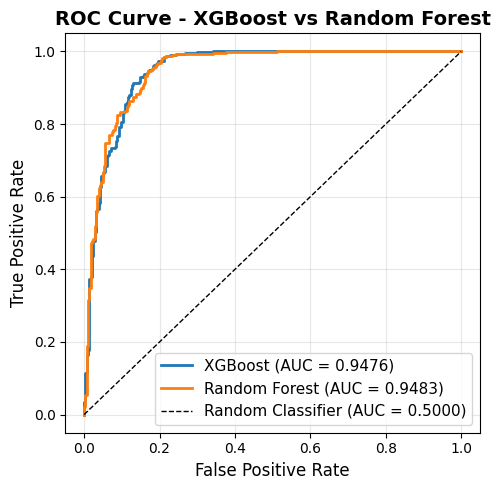

In [20]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# -----------------------------
# AUC and ROC Curve for Both Models
# -----------------------------
models = {"XGBoost": xgb_model, "Random Forest": rf_model}

plt.figure(figsize=(5, 5))

for name, model in models.items():
    # Get predicted probabilities
    y_test_prob = model.predict_proba(X_test)[:,1]
    
    # Calculate AUC
    auc_score = roc_auc_score(y_test, y_test_prob)
    
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
    
    # Plot ROC curve
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})', linewidth=2)
    
    print(f"{name} AUC Score: {auc_score:.4f}")

# Plot diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5000)', linewidth=1)

# Formatting
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - XGBoost vs Random Forest', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
import pickle
import pandas as pd

# Load model and scaler
with open('xgboost_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Feature names
features = [
    "Admission grade", "GDP", "Previous qualification",
    "Curricular units 1st sem (approved)", "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (approved)", "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)", "Age",
    "Tuition fees up to date", "Course", "Scholarship holder", "Debtor",
    "Mother's qualification", "Mother's occupation", "Father's occupation",
    "Displaced", "Daytime/evening attendance", "International"
]

def predict(admission_grade, gdp, prev_qual, sem1_approved, sem1_grade, 
            sem2_approved, sem2_grade, sem2_no_eval, age, tuition_paid, 
            course, scholarship, debtor, mother_qual, mother_occ, 
            father_occ, displaced, daytime, international):
    
    values = [admission_grade, gdp, prev_qual, sem1_approved, sem1_grade,
              sem2_approved, sem2_grade, sem2_no_eval, age, tuition_paid,
              course, scholarship, debtor, mother_qual, mother_occ,
              father_occ, displaced, daytime, international]
    
    input_df = pd.DataFrame([values], columns=features)
    input_scaled = scaler.transform(input_df)
    prediction = model.predict(input_scaled)[0]
    
    result = "Graduate" if prediction == 1 else "Dropout"
    print(result)

# Usage
predict(127.3, 1.74, 1, 5, 13.5, 5, 13.8, 0, 19, 1, 171, 0, 0, 19, 5, 9, 1, 1, 0)
predict(110.0, 1.5, 1, 2, 10.0, 2, 10.5, 3, 23, 0, 171, 0, 1, 12, 3, 4, 1, 0, 1)
predict(120.0, 1.6, 1, 4, 12.0, 4, 12.5, 1, 20, 1, 171, 0, 0, 15, 4, 5, 0, 1, 0)

Graduate
Dropout
Graduate
